In [8]:
import numpy as np
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
import requests

PRECOMPILED_EMBEDDINGS_PATH = "qd/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_circular_7.npz"
EMBEDDING_MODEL_PATH = "qd/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_canon_1.pth"


def fetch_elite_traces_and_reconstructions(
    elites_path="data/ns/elites.json",
    recon_url="http://localhost:4242/reconstruct",
    eval_url="http://localhost:4242/evaluate",
    max_workers_cap=6,
    elite_ids=None,
):
    with open(elites_path, "r") as f:
        elites_data = json.load(f)

    all_elites = elites_data.get("elites", [])
    if elite_ids is None:
        elites = all_elites
    else:
        elite_id_set = set(elite_ids)
        elites = [elite for elite in all_elites if elite.get("id") in elite_id_set]

    def _process_elite(elite):
        elite_id = elite["id"]
        try:
            eval_resp = requests.post(
                eval_url,
                json={
                    "mode": elite["mode"],
                    "id": elite_id,
                    "dataSet": elite["dataSet"],
                    "selectedCells": elite["selectedCells"],
                    "rngMode": elite["rngMode"],
                    "getTraces": True,
                },
                timeout=100,
            )
            eval_resp.raise_for_status()
            eval_data = eval_resp.json()
            fit = eval_data.get("fitness") or {}

            trace_data = {
                "speed_trace": fit.get("speed_trace", None),
                "steer_trace": fit.get("steer_trace", None),
                "brake_trace": fit.get("brake_trace", None),
                "accel_trace": fit.get("accel_trace", None),
                "border_dist_trace": fit.get("border_dist_trace", None),
            }

            embedding_data = fit.get("embedding_data", None)

            recon_resp = requests.post(
                recon_url,
                json={
                    "mode": elite["mode"],
                    "seed": elite_id,
                    "dataSet": elite["dataSet"],
                    "selectedCells": elite["selectedCells"],
                },
                timeout=10,
            )
            recon_resp.raise_for_status()
            recon_data = recon_resp.json()

            return elite_id, {
                "trace_data": trace_data,
                "track": recon_data.get("track", None),
                "embedding_data": embedding_data,
            }, None
        except Exception as e:
            return elite_id, None, str(e.response.text)

    id_to_traces_recon = {}
    max_workers = min(max_workers_cap, max(1, len(elites)))
    print(f"Processing {len(elites)} elites with {max_workers} workers...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(_process_elite, elite) for elite in elites]

        for future in as_completed(futures):
            elite_id, payload, err = future.result()
            if err is not None:
                print(f"Error processing elite {elite_id}: {err}")
                continue
            id_to_traces_recon[elite_id] = payload
            print(f"Got reconstruction for elite {elite_id}")

    print(f"Completed: {len(id_to_traces_recon)}/{len(elites)} elites")
    return id_to_traces_recon, elites

elites_ids = [1038.4087015178613, 972.3440854075254, 812.2860748410124, 437.48558757949786]
id_to_traces_recon, elites = fetch_elite_traces_and_reconstructions(elite_ids=elites_ids)

Processing 4 elites with 4 workers...
Got reconstruction for elite 1038.4087015178613
Got reconstruction for elite 972.3440854075254
Got reconstruction for elite 437.48558757949786
Got reconstruction for elite 812.2860748410124
Completed: 4/4 elites


In [9]:
# import umap

# from qd.data_analysis.utils import project_elites_umap

# _data = np.load(PRECOMPILED_EMBEDDINGS_PATH)
# _embeddings = _data["embeddings"]

# umap_model = umap.UMAP(n_components=2, random_state=67)
# umap_model = umap_model.fit(_embeddings)

# #print umap max and min x,y values
# umap_embeddings = umap_model.transform(_embeddings)

# 

In [10]:
# check keys of elite[0]

from qd.evaluator import EvaluatorMetrics
import copy

evaluator, _ = EvaluatorMetrics.load_pretrained(EMBEDDING_MODEL_PATH)

def perturb_speed(original_embedding_data, perturbation_factor=1.1):
    embedding_data = copy.deepcopy(original_embedding_data)
    if embedding_data is None:
        return None
    
    speed_column_idx = 1
    perturb_row = 20
    embedding_data[perturb_row][speed_column_idx] = embedding_data[perturb_row][speed_column_idx] * perturbation_factor 
    return embedding_data


def measures_from_metrics(array_of_data, evaluator):
    return [evaluator.measure_from_metrics(data) for data in array_of_data]


ids, embedding_data = zip(*(
    (key, value["embedding_data"])
    for key, value in id_to_traces_recon.items()
))

#validate embedding data
for id, data in zip(ids, embedding_data):
    print(data)
    #to numpy array
    data = np.array(data)
    if not EvaluatorMetrics.validate_metrics(metrics=data):
        print(f"Elite ID: {id} has invalid embedding data (too many zeros).")

embeddings = measures_from_metrics(embedding_data, evaluator)



# embedding data deep copy
embedding_data_copy = copy.deepcopy(embedding_data)
# for all embedding_data remove columns [0,3,4,5]
embedding_data_copy = [np.delete(data, [0,3,4,5], axis=1) for data in embedding_data_copy]
# count the number of 0s in the embedding data for each elite
for id, data in zip(ids, embedding_data_copy):
    print(data.shape)
    if data is None:
        print(f"Elite ID: {id} has no embedding data.")
        continue
    flat_data = data.flatten()
    print(flat_data.shape)
    
    zero_count = sum(1 for x in flat_data if x == 0)
    near_zero_count = sum(1 for x in flat_data if 0 < x < 0.01)
    total_count = len(flat_data)
    zero_percentage = (zero_count / total_count) * 100 if total_count > 0 else 0
    near_zero_percentage = (near_zero_count / total_count) * 100 if total_count > 0 else 0
    print(f"Elite ID: {id} has {zero_count} zeros out of {total_count} values ({zero_percentage:.2f}% zeros).")
    print(f"Elite ID: {id} has {near_zero_count} near-zeros (0 < x < 0.01) out of {total_count} values ({near_zero_percentage:.2f}% near-zeros).")
    
    # get separate metrics in order speed steering dist_from_side
    speed_values = data[:, 0]
    steering_values = data[:, 1]
    dist_from_side_values = data[:, 2]

    # count the number of 0s and near-zeros in each metric
    speed_zero_count = sum(1 for x in speed_values if x == 0)
    speed_near_zero_count = sum(1 for x in speed_values if 0 < x < 0.01)
    steering_zero_count = sum(1 for x in steering_values if x == 0)
    steering_near_zero_count = sum(1 for x in steering_values if 0 < x < 0.01)
    dist_from_side_zero_count = sum(1 for x in dist_from_side_values if x == 0)
    dist_from_side_near_zero_count = sum(1 for x in dist_from_side_values if 0 < x < 0.01)
    print(f"Elite ID: {id} - Speed has {speed_zero_count} zeros and {speed_near_zero_count} near-zeros.")
    print(f"Elite ID: {id} - Steering has {steering_zero_count} zeros and {steering_near_zero_count} near-zeros.")
    print(f"Elite ID: {id} - Dist from side has {dist_from_side_zero_count} zeros and {dist_from_side_near_zero_count} near-zeros.")

Loading model from qd/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_canon_1.pth...
Model loaded with latent_dim=32
[[0, 36.8456, 0.0164733, 0, 0.378159, 3, 15.1466], [1, 34.506, 0.0100318, 0, 0.367017, 3, 15.6763], [2, 34.5485, 0.989987, 0.900001, 0, 3, 15.826], [3, 34.8206, 0.915837, 0, 0.00867844, 3, 15.2091], [4, 33.2675, -1, 0, 0.0488692, 3, 13.5363], [5, 31.9475, -0.322351, 0, 0.0645207, 3, 11.5217], [6, 30.3789, 0.501319, 0, 0.275028, 3, 10.3526], [7, 27.4525, 1, 0.1, 0, 2, 10.0991], [8, 24.5699, 0.398844, 0, 0.254015, 2, 10.6579], [9, 21.625, 0.3084, 0, 0.288252, 2, 11.8132], [10, 18.9624, 0.473642, 0, 0.266722, 2, 13.305], [11, 16.4212, 0.712706, 0, 0.236751, 2, 14.3375], [12, 14.1836, -0.0849672, 0, 0.274105, 1, 14.6832], [13, 11.7636, 0.370284, 0, 0.0415245, 1, 14.7159], [14, 9.63289, -0.111668, 0, 0.263172, 1, 14.6589], [15, 8.63767, -0.00442151, 0.4, 0, 1, 14.5937], [16, 8.62113, 0.00855091, 0, 0.242838, 1, 14.5154], [17, 8.36509, 0.0456565, 0, 

In [11]:
# elites = [{ "id": id, "embedding": embedding } for id, embedding in zip(ids, embeddings)]

# project_elites_umap(elites, umap_model, umap_embeddings)

Rendering 4 elites across 1 figure(s)...


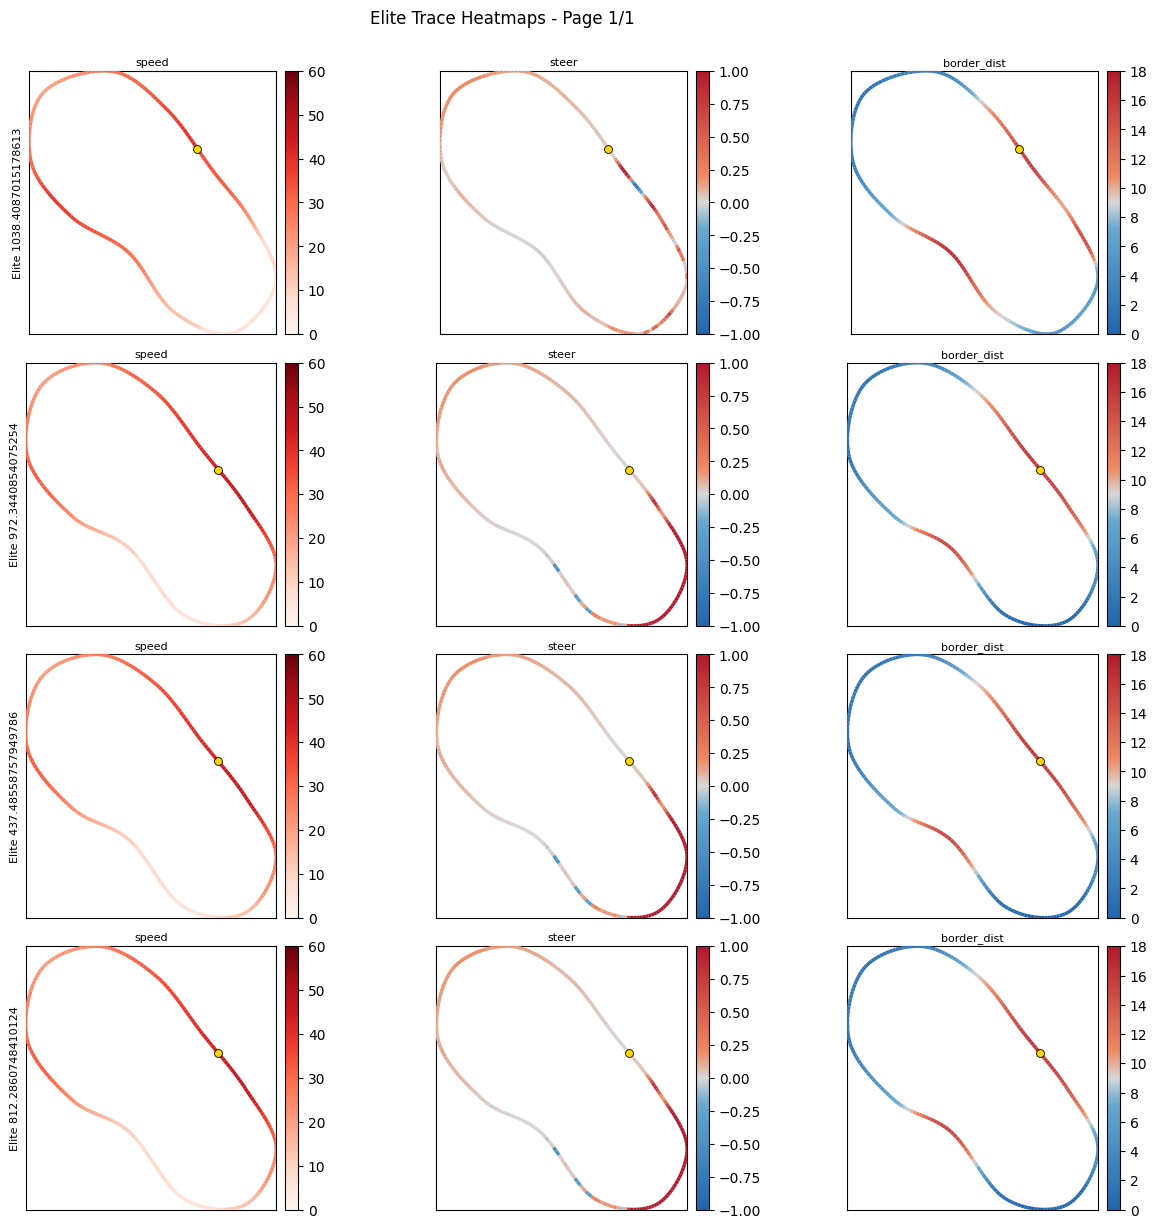

In [12]:
import numpy as np
import importlib
import math
import qd.data_analysis.utils
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

importlib.reload(qd.data_analysis.utils)

from qd.data_analysis.utils import (
    plot_track,
    plot_track_heatmap,
)

# Keep the same metric ordering and fixed ranges used in qd/embeddings/visualizer.py
TRACE_METRICS = ["speed_trace","steer_trace", "border_dist_trace"]
TRACE_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "accel_trace": (0, 1),
    "brake_trace": (0, 1),
    "border_dist_trace": (0, 18),
}

CUSTOM_BURD = LinearSegmentedColormap.from_list(
    "custom_burd",
    [
        (0.0, (33 / 255.0, 102 / 255.0, 172 / 255.0)),
        (0.4, (103 / 255.0, 169 / 255.0, 207 / 255.0)),
        (0.5, (215 / 255.0, 215 / 255.0, 215 / 255.0)),
        (0.6, (239 / 255.0, 138 / 255.0, 98 / 255.0)),
        (1.0, (178 / 255.0, 24 / 255.0, 43 / 255.0)),
    ],
    N=256,
)

# Use red heatmap for all traces except steer_trace.
TRACE_CMAPS = {
    "speed_trace": "Reds",
    "accel_trace": "Reds",
    "steer_trace": CUSTOM_BURD,
    "brake_trace": "Reds",
    "border_dist_trace": CUSTOM_BURD,
}

ROWS_PER_FIGURE = 5

def _clean_trace(trace):
    if not trace:
        return []
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return []
    values = arr[:, 0]
    distances = arr[:, 1]
    finite = np.isfinite(values) & np.isfinite(distances)
    values, distances = values[finite], distances[finite]
    if len(values) < 2:
        return []
    return list(zip(values.tolist(), distances.tolist()))

def _plot_start_point(ax, track):
    if not track:
        return
    start = track[0]
    sx, sy = start.get("x"), start.get("y")
    if sx is None or sy is None:
        return
    ax.scatter(
        [sx],
        [sy],
        s=32,
        c="gold",
        edgecolors="black",
        linewidths=0.6,
        zorder=10,
        marker="o",
    )

elite_items = list(id_to_traces_recon.items())
if len(elite_items) == 0:
    print("No elites found in id_to_traces_recon. Run Cell 1 first.")
else:
    ncols = len(TRACE_METRICS)
    total_pages = math.ceil(len(elite_items) / ROWS_PER_FIGURE)
    print(f"Rendering {len(elite_items)} elites across {total_pages} figure(s)...")

    for page_num in range(total_pages):
        start_idx = page_num * ROWS_PER_FIGURE
        page = elite_items[start_idx : start_idx + ROWS_PER_FIGURE]
        nrows = len(page)

        fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.1 * nrows), squeeze=False)

        for r, (elite_id, content) in enumerate(page):
            track = content.get("track", None)
            trace_data = content.get("trace_data", {})

            for c, metric in enumerate(TRACE_METRICS):
                ax = axes[r, c]
                metric_trace = _clean_trace(trace_data.get(metric, None))
                
                metric_label = metric.replace("_trace", "")
                title = f"{metric_label}"

                if track and metric_trace:
                    plot_track_heatmap(
                        ax,
                        track,
                        metric_trace,
                        title=title,
                        cmap=TRACE_CMAPS.get(metric, "Reds"),
                        color_range=TRACE_RANGES.get(metric),
                    )
                    _plot_start_point(ax, track)
                else:
                    if track:
                        plot_track(ax, track, title=title, track_color="lightgray")
                        _plot_start_point(ax, track)
                    else:
                        ax.set_axis_off()
                    ax.text(0.5, 0.5, "missing data", ha="center", va="center", transform=ax.transAxes, fontsize=8)

                if c == 0:
                    ax.set_ylabel(f"Elite {elite_id}", fontsize=8)

        fig.suptitle(f"Elite Trace Heatmaps - Page {page_num + 1}/{total_pages}", fontsize=12)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

Rendering 4 elites across 1 figure(s)...


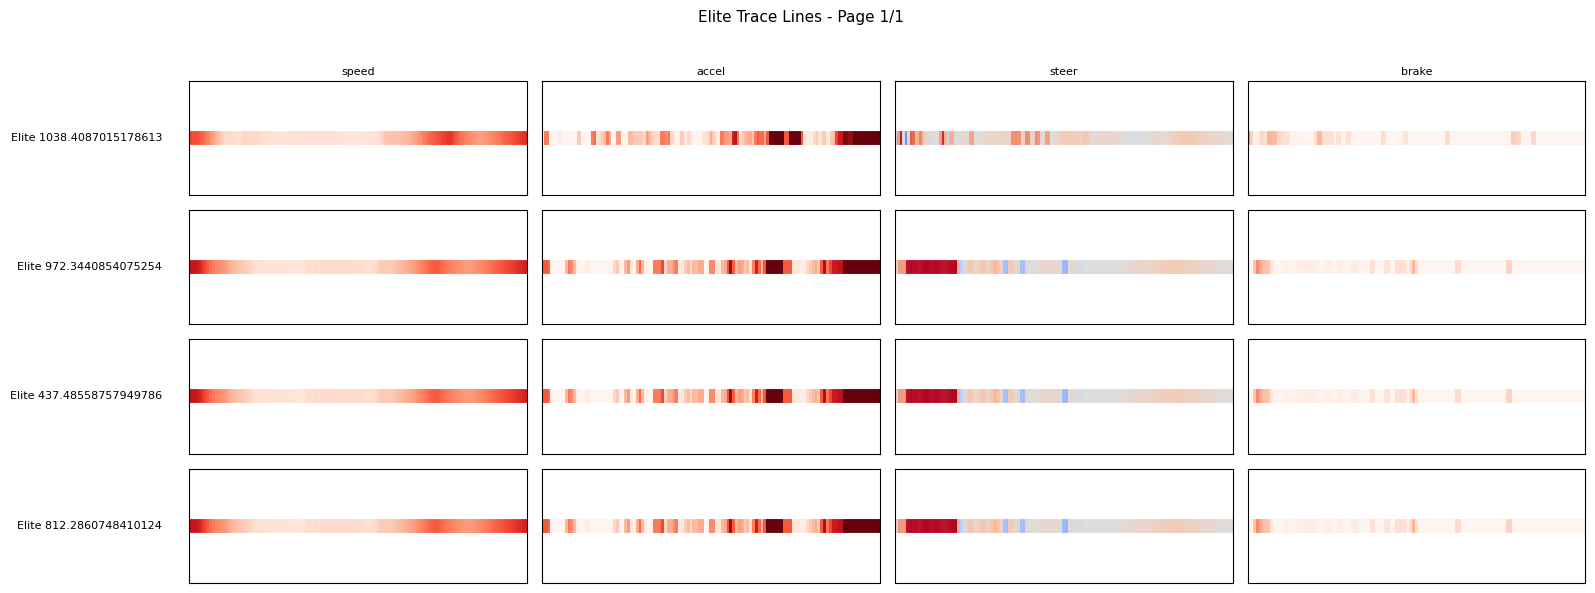

In [13]:
import math
import importlib
import numpy as np
import matplotlib.pyplot as plt

import qd.data_analysis.utils as analysis_utils
importlib.reload(analysis_utils)

from qd.data_analysis.utils import plot_trace_fixed_line

TRACE_METRICS = ["speed_trace", "accel_trace", "steer_trace", "brake_trace"]
TRACE_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "accel_trace": (0, 1),
    "brake_trace": (0, 1),
}
TRACE_CMAPS = {
    "speed_trace": "Reds",
    "accel_trace": "Reds",
    "steer_trace": "coolwarm",
    "brake_trace": "Reds",
}

ROWS_PER_FIGURE = 8

def _extract_trace_values(trace):
    if not trace:
        return np.array([])
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 1:
        return np.array([])
    values = arr[:, 0]
    values = values[np.isfinite(values)]
    return values

if "id_to_traces_recon" not in globals():
    print("id_to_traces_recon is not available. Run Cell 1 first.")
else:
    elite_items = list(id_to_traces_recon.items())
    if len(elite_items) == 0:
        print("No elites found in id_to_traces_recon. Run Cell 1 first.")
    else:
        ncols = len(TRACE_METRICS)
        total_pages = math.ceil(len(elite_items) / ROWS_PER_FIGURE)
        print(f"Rendering {len(elite_items)} elites across {total_pages} figure(s)...")

        for page_num in range(total_pages):
            start_idx = page_num * ROWS_PER_FIGURE
            page = elite_items[start_idx : start_idx + ROWS_PER_FIGURE]
            nrows = len(page)

            fig, axes = plt.subplots(
                nrows,
                ncols,
                figsize=(4.0 * ncols, 1.2 * nrows + 1.2),
                squeeze=False,
            )

            for r, (elite_id, content) in enumerate(page):
                trace_data = content.get("trace_data", {})

                for c, metric in enumerate(TRACE_METRICS):
                    ax = axes[r, c]
                    values = _extract_trace_values(trace_data.get(metric, None))
                    title = metric.replace("_trace", "")

                    if values.size >= 2:
                        plot_trace_fixed_line(
                            ax,
                            values,
                            line_length=1.0,
                            y=0.0,
                            title=title if r == 0 else None,
                            cmap=TRACE_CMAPS.get(metric, "Reds"),
                            color_range=TRACE_RANGES.get(metric),
                            linewidth=10,
                            show_colorbar=False,
                        )
                    else:
                        ax.set_axis_off()
                        if r == 0:
                            ax.set_title(title, fontsize=8, pad=4)
                        ax.text(
                            0.5,
                            0.5,
                            "missing data",
                            ha="center",
                            va="center",
                            transform=ax.transAxes,
                            fontsize=7,
                        )

                    if c == 0:
                        ax.text(
                            -0.08,
                            0.5,
                            f"Elite {elite_id}",
                            transform=ax.transAxes,
                            ha="right",
                            va="center",
                            fontsize=8,
                        )

            fig.suptitle(f"Elite Trace Lines - Page {page_num + 1}/{total_pages}", fontsize=11)
            plt.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()
            
